# Rapport d'analyse et guide operationnel : Gestion des aleas et adaptation dynamique du bloc operatoire

Réalisé par Youri et Mathys.

Ce notebook decrit le systeme de gestion des aleas et d'adaptation dynamique du bloc operatoire, puis le teste sur un jeu de 30 patients.

Un bloc operatoire varie tous les jours :
- des urgences arrivent apres la programmation, il faut les integrer sans tout deplacer ;
- des patients annulent, ce qui libere du temps de salle et des lits ;
- des lits sont fermes (effectifs, isolement) ;
- des vacations debordent (intervention plus longue, preparation retardee).

Le systeme traite ces aleas de deux facons :
1. **En amont** : il prepare quatre profils de planning (nominal, robuste bufferise, securite lits, alternatif Date B) et une proposition Date A / Date B par patient.
2. **Le jour meme** : il adapte le planning en gelant les interventions passees, en inserant les urgences dans leur fenetre clinique et en deplacant le moins de patients possible.

## 1. Imports et initialisation de l'environnement

On charge `numpy`, `pandas`, `matplotlib` et les modules `optimizer`, `aleas` et `plotting` du package `optimiseur`.

*Réalisé par Youri.*

In [1]:
import os
import sys
from pathlib import Path

# Fix pour OpenBLAS sous Windows / Python 3.14
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rendre le package optimiseur importable depuis la racine du depot
NOTEBOOK_DIR = Path.cwd()
REPO = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from optimiseur import optimizer as op
from optimiseur import aleas as al
from optimiseur import plotting as pl

print(f"Environnement initialise. Racine du depot : {REPO}")

Environnement initialise. Racine du depot : /home/youri/projets/IAS__metaheuristics


## 2. Generation des donnees de base du bloc operatoire

Le jeu de test represente une semaine de bloc : 30 patients electifs sur 5 jours, 4 vacations de 240 minutes par jour (une par specialite : Orthopedie, Digestif, Cardio, ORL) et 35 lits d'hospitalisation.

*Réalisé par Mathys.*

In [2]:
patients_df, vacations_df = op.generate_test_data(
    n_patients=30,
    n_days=5,
    vacations_par_jour_par_specialite=1,
    seed=42,
)

print(f"Patients generes ({len(patients_df)}) :")
display(patients_df.head(6))

print(f"\nVacations disponibles ({len(vacations_df)}) :")
display(vacations_df.head(6))

Patients generes (30) :


,patient_id,specialite,duree_operatoire,duree_sejour
0,0,Orthopedie,122,3
1,1,Digestif,81,4
2,2,Orthopedie,113,1
3,3,Orthopedie,93,4
4,4,Cardio,121,3
5,5,ORL,91,0



Vacations disponibles (20) :


,vacation_id,jour,specialite,capacite_min
0,0,0,Orthopedie,240
1,1,0,Digestif,240
2,2,0,Cardio,240
3,3,0,ORL,240
4,4,1,Orthopedie,240
5,5,1,Digestif,240


## 3. Optimisation du planning nominal initial

Le probleme est modelise par une instance `PlanningProblem`, puis les cinq metaheuristiques cherchent le meilleur planning.

In [3]:
problem_nominal = op.PlanningProblem(
    patients_df,
    vacations_df,
    lits_capacity=35,
    w_vacation=5.0,
    w_lits=3.0,
    w_balance=0.05,
)

print(f"Probleme initialise : {problem_nominal.n_patients} patients, {problem_nominal.n_vacations} vacations, {problem_nominal.n_days} jours.")

# Optimisation avec les 5 metaheuristiques
resultats_init = op.optimize_planning(patients_df, vacations_df, lits_capacity=35, seed=42)

for nom, r in resultats_init.items():
    print(f"{nom:<16s} fitness = {r.meilleure_fitness:10.3f}   temps = {op.format_duree(r.duree_s):>9s}")

meilleure_methode = max(resultats_init, key=lambda n: resultats_init[n].meilleure_fitness)
solution_nominale = resultats_init[meilleure_methode].meilleure_solution
print(f"\n-> Meilleure methode retenue pour le planning nominal : {meilleure_methode}")

Probleme initialise : 30 patients, 20 vacations, 5 jours.


Recuit simule    fitness =     -1.566   temps = 186.76 ms
Tabou            fitness =     -1.566   temps = 222.65 ms
Genetique        fitness =     -2.016   temps = 395.49 ms
Tabou x Recuit   fitness =     -1.566   temps = 373.78 ms
Fourmis (ACO)    fitness =     -2.060   temps =    1.14 s

-> Meilleure methode retenue pour le planning nominal : Recuit simule


### Visualisation du planning nominal et de l'occupation des lits

*Réalisé par Youri.*

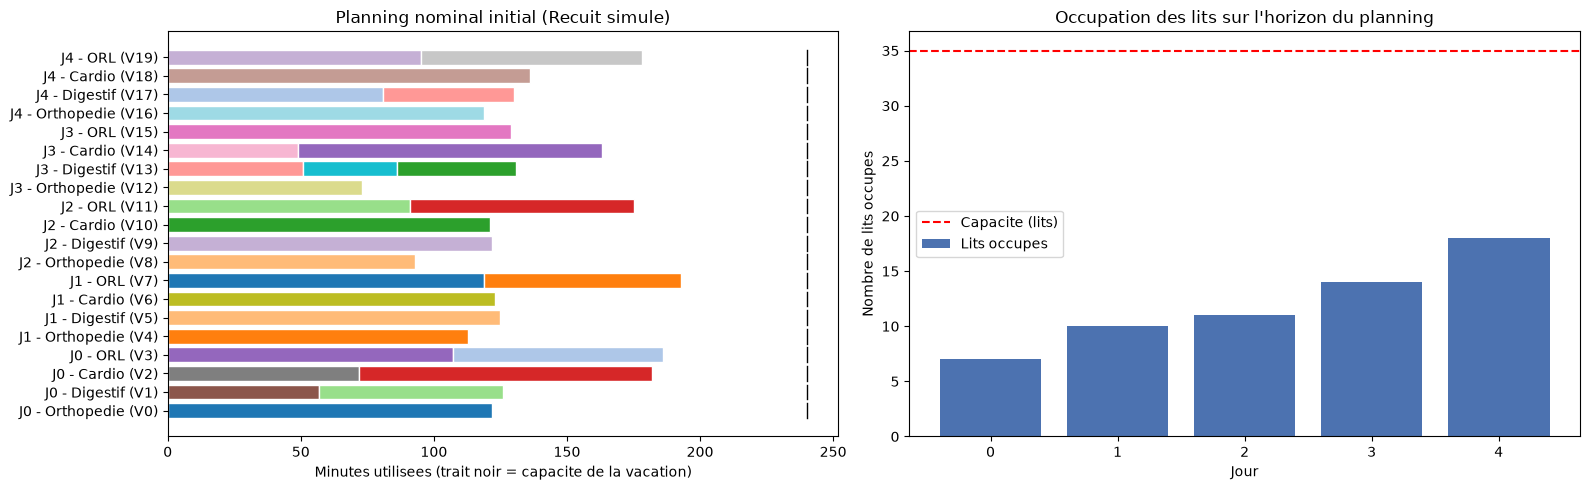

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
pl.plot_planning(problem_nominal, solution_nominale, titre=f"Planning nominal initial ({meilleure_methode})", ax=axes[0])
pl.plot_occupation_lits(problem_nominal, solution_nominale, ax=axes[1])
plt.show()

## 4. Approche 1 : Generation proactive de plannings alternatifs

Plutot que de subir les imprevus, l'etablissement peut preparer plusieurs plannings a l'avance. Le module en produit quatre :

1. **Nominal** : capacite utilisee a 100 %, sans marge.
2. **Robuste Bufferise** : 15 % de capacite bloc et de lits gardes en reserve pour absorber les imprevus sans decaler de patient.
3. **Securite Lits** : l'occupation est lissee en priorite pour eviter les pics.
4. **Alternatif Diversifie (Date B)** : une seconde affectation de bonne qualite, assez differente du nominal pour offrir un vrai choix.

In [5]:
plannings_alternatifs = al.generer_plannings_alternatifs(
    problem_nominal,
    solution_nominale=solution_nominale,
    marge_buffer_bloc=0.15,
    marge_buffer_lits=0.15,
    seed=42,
)

metrics = []
for nom, alt in plannings_alternatifs.items():
    metrics.append({
        "Profil": nom,
        "Fitness": f"{alt.fitness:.2f}",
        "Depassement bloc (min)": f"{alt.overflow_vacation:.1f}",
        "Depassement lits": f"{alt.overflow_lits:.1f}",
        "Marge moy. bloc": f"{alt.marge_moyenne_bloc_min:.1f} min",
        "Pic maximal lits": f"{alt.pic_lits} lits",
        "Divergence vs Nominal": f"{alt.taux_patients_differents*100:.1f} %",
    })

display(pd.DataFrame(metrics))

,Profil,Fitness,Depassement bloc (min),Depassement lits,Marge moy. bloc,Pic maximal lits,Divergence vs Nominal
0,Nominal,-1.57,0.0,0.0,103.0 min,18 lits,0.0 %
1,Robuste_Buffer,-1.57,0.0,0.0,103.0 min,17 lits,73.3 %
2,Securite_Lits,-1.57,0.0,0.0,103.0 min,18 lits,90.0 %
3,Alternatif_Date_B,-1.57,0.0,0.0,103.0 min,19 lits,100.0 %


### Comparaison graphique des 4 profils alternatifs

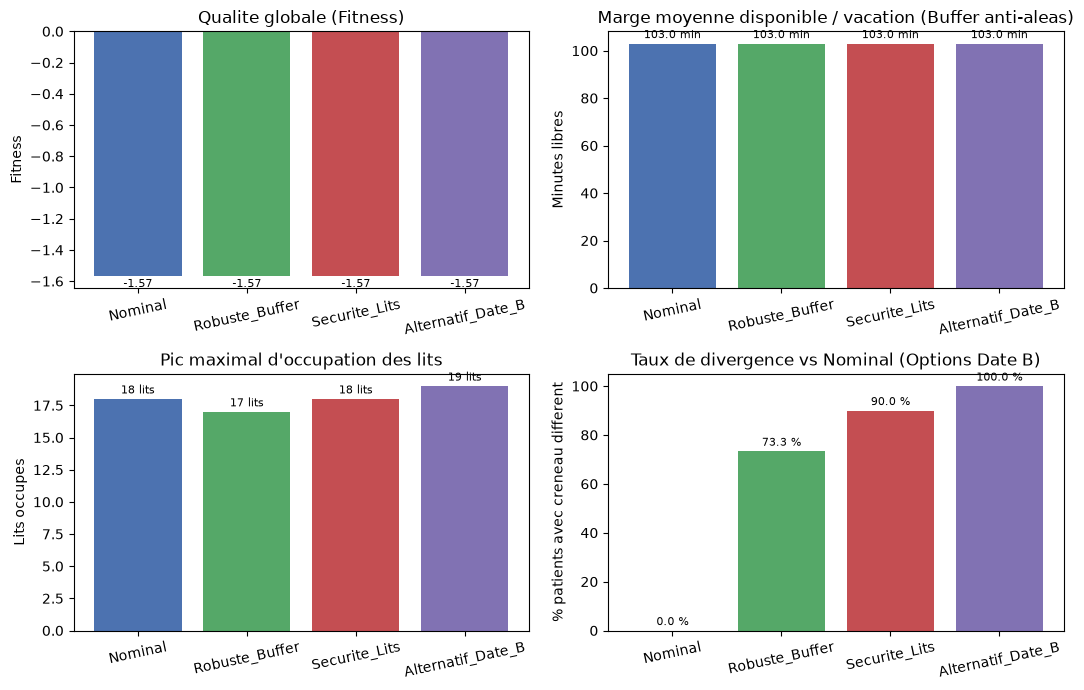

In [6]:
fig_alt = pl.plot_comparaison_alternatives(plannings_alternatifs)
plt.show()

### Aide a la decision medicale : Tableau des options Date A / Date B

A la consultation preoperatoire, le chirurgien ou sa secretaire dispose de deux dates pour chaque patient : la date nominale et une alternative qui tient dans les capacites bloc et lits.

*Réalisé par Mathys.*

In [7]:
df_dates_ab = al.extraire_options_date_a_b(
    problem_nominal,
    plannings_alternatifs["Nominal"].solution,
    plannings_alternatifs["Alternatif_Date_B"].solution,
)

nb_distincts = df_dates_ab["jours_distincts"].sum()
print(f"Tableau Date A / Date B pour les 30 patients ({nb_distincts} patients avec jours distincts) :")
display(df_dates_ab.head(10))

Tableau Date A / Date B pour les 30 patients (30 patients avec jours distincts) :


,patient_id,specialite,duree_operatoire,duree_sejour,option_A_jour,option_A_vacation,option_B_jour,option_B_vacation,jours_distincts,meme_creneau,recommandation
0,0,Orthopedie,122,3,0,0,3,12,True,False,Alternative a J3 proposee
1,10,Digestif,57,0,0,1,4,17,True,False,Alternative a J4 proposee
2,25,Digestif,69,1,0,1,4,17,True,False,Alternative a J4 proposee
3,14,Cardio,72,0,0,2,2,10,True,False,Alternative a J2 proposee
4,26,Cardio,110,4,0,2,2,10,True,False,Alternative a J2 proposee
5,8,ORL,107,2,0,3,2,11,True,False,Alternative a J2 proposee
6,21,ORL,79,1,0,3,2,11,True,False,Alternative a J2 proposee
7,2,Orthopedie,113,1,1,4,0,0,True,False,Alternative a J0 proposee
8,23,Digestif,125,0,1,5,3,13,True,False,Alternative a J3 proposee
9,16,Cardio,123,3,1,6,4,18,True,False,Alternative a J4 proposee


## 5. Modelisation et injection des 4 types d'aleas

Le systeme traite quatre types d'aleas :

| Alea | Classe | Effet sur le planning | Attributs |
|---|---|---|---|
| Urgence | `Urgence` | Ajoute un patient hors programmation | `specialite`, `duree_operatoire`, `duree_sejour`, `jour_apparition`, `delai_max_jours`, `priorite` |
| Annulation | `Annulation` | Retire un patient programme et libere son creneau et ses lits | `patient_id`, `jour_notification` |
| Indisponibilite lits | `IndisponibiliteLits` | Baisse la capacite d'accueil sur une periode | `jour_debut`, `jour_fin`, `lits_perdus` |
| Retard bloc | `RetardBloc` | Ampute la capacite utile d'une vacation | `vacation_id`, `retard_min` |

Au Jour 1, ces quatre aleas tombent en meme temps sur le planning nominal :

1. **Deux urgences** : `URG_1` (Orthopedie, 90 min, sejour 2 jours, a operer le jour meme) et `URG_2` (Cardio, 75 min, sejour 3 jours, sous 48 h).
2. **Une annulation** : un patient programme au jour 2 annule pour contre-indication anesthesique.
3. **Une indisponibilite de lits** : 5 lits fermes aux jours 1 et 2, faute d'infirmiers.
4. **Un retard de bloc** : une vacation de cardiologie demarre avec 45 minutes de retard apres une complication technique.

*Réalisé par Youri.*

In [8]:
jour_courant = 1

scenario = al.ScenarioAleas(nom="Scenario Crise Reelle au Jour 1")

# 1. Ajout de 2 urgences
scenario.ajouter_urgence(
    patient_id="URG_1",
    specialite="Orthopedie",
    duree_operatoire=90.0,
    duree_sejour=2,
    jour_apparition=jour_courant,
    delai_max_jours=0,  # le jour meme imperativement
    priorite=1,
    motif="Fracture ouverte - Urgence vitale",
)

scenario.ajouter_urgence(
    patient_id="URG_2",
    specialite="Cardio",
    duree_operatoire=75.0,
    duree_sejour=3,
    jour_apparition=jour_courant,
    delai_max_jours=1,  # sous 24h a 48h
    priorite=2,
    motif="Syndrome coronarien aigu",
)

# 2. Ajout d'une annulation parmi les patients programmes a partir de Jour 1
pid_annule = None
for pid, vac_idx in solution_nominale.items():
    if problem_nominal._vac_day[vac_idx] >= jour_courant:
        pid_annule = problem_nominal.patients.loc[pid, "patient_id"]
        break

if pid_annule is not None:
    scenario.ajouter_annulation(
        patient_id=pid_annule,
        jour_notification=jour_courant,
        motif="Contre-indication anesthesique (bilan biologique anormal)",
    )

# 3. Indisponibilite de 5 lits au Jour 1 et Jour 2
scenario.ajouter_indisponibilite_lits(
    jour_debut=jour_courant,
    jour_fin=min(problem_nominal.n_days - 1, jour_courant + 1),
    lits_perdus=5,
    motif="Tension RH soignante / chambres d'isolement requises",
)

# 4. Retard de bloc de 45 minutes sur une vacation du jour courant
vac_jour1 = vacations_df[vacations_df["jour"] == jour_courant].iloc[0]
scenario.ajouter_retard_bloc(
    vacation_id=int(vac_jour1["vacation_id"]),
    retard_min=45.0,
    motif="Prolongation premiere intervention suite a complication",
)

print(scenario.resume())

Scenario : Scenario Crise Reelle au Jour 1 (5 aleas au total)
  - Urgences : 2
  - Annulations : 1
  - Indisponibilites lits : 1
  - Retards bloc : 1


## 6. Approche 2 : Adaptation dynamique

L'adaptation reprend le planning nominal et le corrige sous trois contraintes :

- les interventions du Jour 0 sont gelees ;
- le patient annule est retire et les urgences sont placees dans leur fenetre clinique ;
- un patient electif ne bouge que si c'est necessaire pour ramener le bloc ou les lits dans leurs capacites.

Le moteur est une recherche taboue. Les mouvements recents sont stockes dans une `collections.deque` de taille fixe : `maxlen=25` dans `adapter_planning`, `tabu_size=20` par defaut dans `tabu_search`. Une fois pleine, la liste evince le mouvement le plus ancien, ce qui evite de defaire puis refaire la meme affectation. Un mouvement tabou reste autorise s'il ameliore le meilleur score connu (critere d'aspiration). Les methodes `Tabou`, `Tabou x Recuit`, `Genetique x Tabou` et `Fourmis x Tabou` du planning nominal utilisent la meme structure ; un mouvement y est code `("reassign", patient, vacation)` ou `("swap", patient_1, patient_2)`.

In [9]:
adaptation_result = al.adapter_planning(
    problem=problem_nominal,
    solution_initiale=solution_nominale,
    scenario=scenario,
    jour_courant=jour_courant,
    w_perturbation=3.0,      # cout d'instabilite pour un deplacement meme jour
    w_changement_jour=8.0,   # penalite forte si on change la date du patient
    n_iter=350,
    seed=42,
)

print(adaptation_result.rapport)

             RAPPORT D'ADAPTATION DYNAMIQUE DU BLOC OPERATOIRE
Point d'etape : Jour courant 1 | Temps d'optimisation reactive : 456.2 ms
Qualite du planning : Fitness initiale =    -1.57 -> Fitness adaptee =    -1.94
------------------------------------------------------------------------------
1. SYNTHESE DES ALEAS CONSIDERES :
   - 2 Urgence(s) arrivee(s)
   - 1 Annulation(s) validee(s)
   - 1 Periode(s) de tension / lits indisponibles
   - 1 Vacation(s) impactee(s) par un retard de bloc
------------------------------------------------------------------------------
2. GESTION DES HISTORIQUES ET CONTRAINTES DE STABILITE :
   - Patients geles (passes) : 7 patient(s) sanctuarise(s) (jours < 1)
   - Perturbation de planning : 1 patient(s) deplace(s) au total
------------------------------------------------------------------------------
3. INTEGRATION DES URGENCES :
   [+] Urgence URG_1 (Orthopedie, 90.0 min) -> Affectee au Jour 1, Vacation 4
   [+] Urgence URG_2 (Cardio, 75.0 min) -> Aff

### Visualisation comparative avant / apres adaptation dynamique

Le diagramme compare les deux plannings. En haut, l'initial : le patient qui va annuler apparait en rouge hache. En bas, l'adapte : urgences en rouge (`URG`), retard de salle en gris, patients deplaces en orange avec un asterisque.

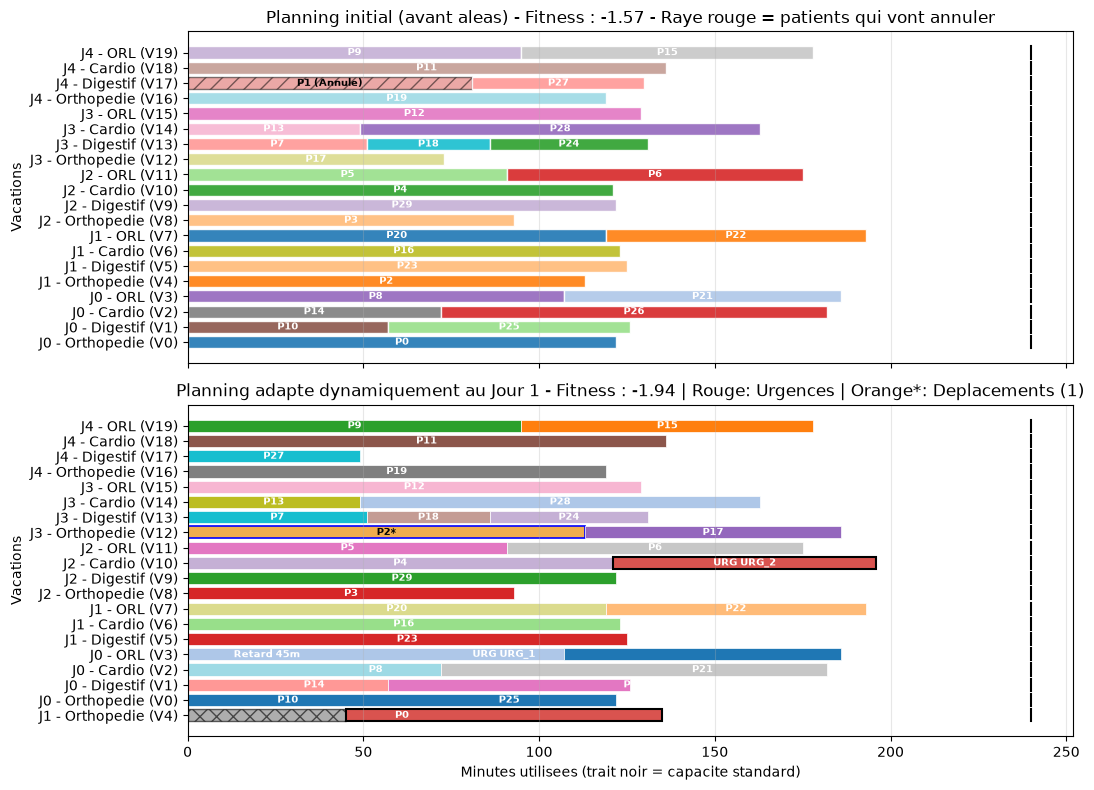

In [10]:
fig_adap = pl.plot_adaptation_dynamique(adaptation_result)
plt.show()

### Impact sur l'hospitalisation et l'occupation des lits

*Réalisé par Mathys.*

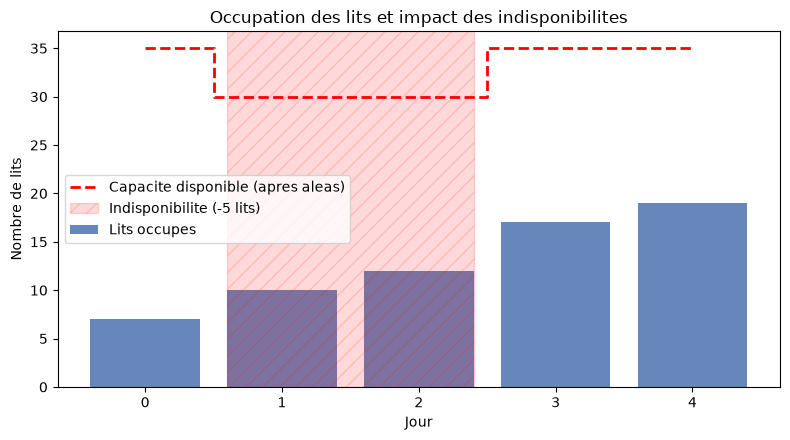

In [11]:
fig_lits_aleas = pl.plot_occupation_lits_aleas(
    adaptation_result.problem_adapte,
    adaptation_result.solution_adaptee,
    indisponibilites=scenario.indisponibilites_lits,
)
plt.show()

## 7. Analyse detaillee des arbitrages d'adaptation

Liste des patients dont le creneau a change pendant l'adaptation, avec le motif.

*Réalisé par Youri.*

In [12]:
if adaptation_result.patients_deplaces:
    lignes_dep = []
    for d in adaptation_result.patients_deplaces:
        lignes_dep.append({
            "Patient": d.patient_id,
            "Avant (Jour, Vac)": f"J{d.jour_avant} - V{d.vacation_avant}",
            "Apres (Jour, Vac)": f"J{d.jour_apres} - V{d.vacation_apres}",
            "Type de changement": "Autre jour" if d.est_changement_jour else "Meme jour (autre salle)",
            "Motif": d.motif,
        })
    df_dep = pd.DataFrame(lignes_dep)
    print("Tableau des deplacements de patients realises :")
    display(df_dep)
else:
    print("Aucun deplacement de patient n'a ete necessaire : les marges du planning ont absorbe l'integralite des aleas !")

Tableau des deplacements de patients realises :


,Patient,"Avant (Jour, Vac)","Apres (Jour, Vac)",Type de changement,Motif
0,2,J1 - V4,J3 - V12,Autre jour,Decalage sur autre jour pour absorber aleas


## 8. Synthese

Au Jour 1, tout tombe en meme temps : deux urgences, une annulation, 5 lits fermes aux jours 1 et 2 et 45 minutes de retard. L'adaptation absorbe le choc en deplacant un seul patient electif (P2, de J1 V4 vers J3 V12). Les urgences sont placees dans leur fenetre (URG_1 le jour meme, URG_2 sous 48 h) et les 7 patients deja operes restent geles. La fitness passe de -1.57 a -1.94 : le cout augmente, mais le planning reste realisable.

Deux points a retenir :

- les quatre profils alternatifs ont la meme fitness (-1.57) avec des affectations tres differentes (73 % a 100 % de divergence pour les profils non nominaux). Sur cette instance, la marge vient de la redistribution, pas d'une meilleure solution ;
- le tableau Date A / Date B donne une seconde date pour chaque patient, impacts lits compris.

Les poids d'adaptation (`w_perturbation=3`, `w_changement_jour=8`) favorisent la stabilite. Un service qui accepte plus de mouvements peut les baisser.

*Réalisé par Mathys.*